# plotastro — tutorial

Publication-quality matplotlib figures for astronomy journals. This notebook
walks through every feature:

1. [Quick start](#1.-Quick-start)
2. [Figure sizes that match your journal](#2.-Figure-sizes-that-match-your-journal)
3. [The colour palettes](#3.-The-colour-palettes)
4. [Checking colour-blind accessibility](#4.-Checking-colour-blind-accessibility)
5. [Markers and line styles](#5.-Markers-and-line-styles)
6. [Panel labels](#6.-Panel-labels)
7. [Real-world examples](#7.-Real-world-examples)
8. [Switching journals](#8.-Switching-journals)
9. [LaTeX text rendering](#9.-LaTeX-text-rendering)
10. [Saving figures for submission](#10.-Saving-figures-for-submission)
11. [Author lists from a CSV](#11.-Author-lists-from-a-CSV)

Install with `pip install plotastro` (or `pip install -e .` from a clone).
See `README.md` for the full reference documentation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import plotastro as pa
except ImportError:                      # running from a clone without installing
    import sys; sys.path.insert(0, "../src")
    import plotastro as pa

print("plotastro", pa.__version__)
rng = np.random.default_rng(1)

plotastro 0+unknown


## 1. Quick start

`pa.set_style(journal)` activates one of the journal styles, and
`pa.subplots()` creates a figure that is **exactly one column wide** for that
journal, with a golden-ratio height. Because the figure already has the right
physical size, you include it in LaTeX **without any scaling** — so the fonts
on the page come out exactly as designed (~8–9 pt, matching the journal's own
text).

Available journals: `mnras`, `rasti`, `aanda` (A&A), `apj`/`apjl`, `oja`,
`prd`/`prl`, `jcap`, `natastro` (Nature Astronomy), plus `thesis` and
`beamer` width presets.

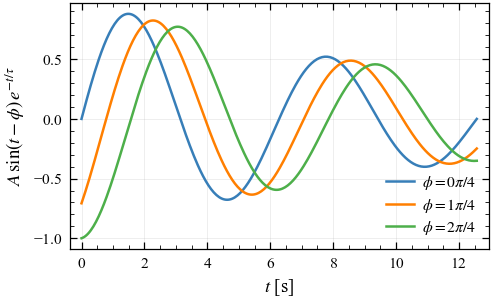

In [2]:
pa.set_style("mnras")

x = np.linspace(0, 4 * np.pi, 300)

fig, ax = pa.subplots()
for i in range(3):
    ax.plot(x, np.sin(x - i * np.pi / 4) * np.exp(-x / 12), label=f"$\\phi = {i}\\pi/4$")
ax.set_xlabel("$t$ [s]")
ax.set_ylabel(r"$A\,\sin(t-\phi)\,e^{-t/\tau}$")
ax.legend()
plt.show()

In LaTeX you would then include it with:

```latex
\begin{figure}
    \includegraphics{myplot.pdf}   % no [width=...] needed!
    \caption{...}
\end{figure}
```

### Prefer plain matplotlib? Nothing new to learn

Importing plotastro registers the styles with matplotlib itself, so you can
ignore every helper in this package and keep writing ordinary matplotlib —
one import and one `plt.style.use` line is the entire integration. The
default figure size baked into each style is already the journal's column
width:

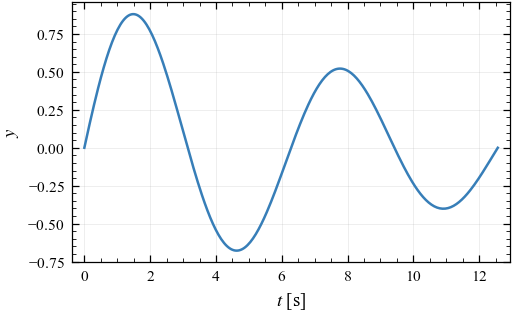

In [3]:
import plotastro                    # just to register the styles

plt.style.use("aanda")              # plain matplotlib from here on
fig, ax = plt.subplots()            # already A&A column-sized
ax.plot(x, np.sin(x) * np.exp(-x / 12))
ax.set_xlabel("$t$ [s]")
ax.set_ylabel("$y$")
plt.show()

pa.set_style("mnras")               # back to the helpers for this tutorial

## 2. Figure sizes that match your journal

Why bother? If you make a 6-inch-wide figure and LaTeX squeezes it into an
84 mm column, everything shrinks by ~50% — your 10 pt labels become unreadable
5 pt labels. The fix is to build the figure at its final printed size.

`pa.figsize()` knows the column and full text widths of each journal:

| argument | meaning |
|---|---|
| `width="column"` | one column wide (the default) |
| `width="full"` | full text width (both columns) |
| `width=252.0` | any width in LaTeX points (get yours with `\the\columnwidth`) |
| `fraction=0.5` | a fraction of that width |
| `aspect=1` | height/width of one panel (default: golden ratio ≈ 0.618) |
| `nrows, ncols` | height scales with the subplot grid |

In [4]:
print("one column      :", pa.figsize("column"))
print("full width      :", pa.figsize("full"))
print("half a column   :", pa.figsize("column", fraction=0.5))
print("square panel    :", pa.figsize("column", aspect=1))
print("A&A column      :", pa.figsize("column", journal="aanda"))

one column      : (3.3208800332088004, 2.0524167330839185)
full width      : (6.973848069738481, 4.310075139476229)
half a column   : (1.6604400166044002, 1.0262083665419592)
square panel    : (3.3208800332088004, 3.3208800332088004)
A&A column      : (3.464508094645081, 2.1411837567897978)


`pa.subplots()` accepts the same arguments plus everything `plt.subplots`
takes (`sharex`, `gridspec_kw`, ...). A full-width two-panel figure:

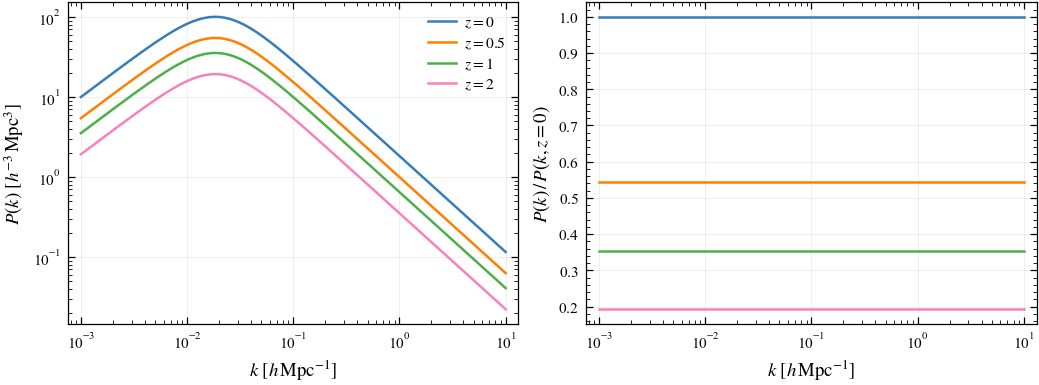

In [5]:
k = np.logspace(-3, 1, 300)

fig, axes = pa.subplots(1, 2, width="full", aspect=0.75, sharex=True)
for z in [0, 0.5, 1, 2]:
    pk = 1e4 * k / (1 + (k / 0.02) ** 2.2) / (1 + z) ** 1.5
    axes[0].loglog(k, pk, label=f"$z = {z}$")
    axes[1].semilogx(k, pk / (1e4 * k / (1 + (k / 0.02) ** 2.2)))
axes[0].set_ylabel(r"$P(k)\ [h^{-3}\,\mathrm{Mpc}^3]$")
axes[1].set_ylabel(r"$P(k)\,/\,P(k, z=0)$")
for ax in axes:
    ax.set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
axes[0].legend()
plt.show()

## 3. The colour palettes

The default colour cycle is designed so that **any two neighbouring colours
remain distinguishable with the most common forms of colour-vision deficiency**
(deuteranopia and protanopia, ~5% of male readers — MNRAS explicitly asks for
colour-blind-friendly figures).

- **C0–C8** are a colour-blind-safe re-ordering of the ColorBrewer *Set1*
  palette: red and green are pushed far apart in the cycle (C7 and C2), so
  consecutive lines never form the classic problem pair, and adjacent colours
  differ in *lightness* as well as hue.
- **C9–C11** are light companions (from Tableau's *Color Blind 10*): perfect
  for uncertainty bands, reference lines, or de-emphasised data under a
  saturated line of the same hue.

Every colour is available by name via `pa.COLORS`:

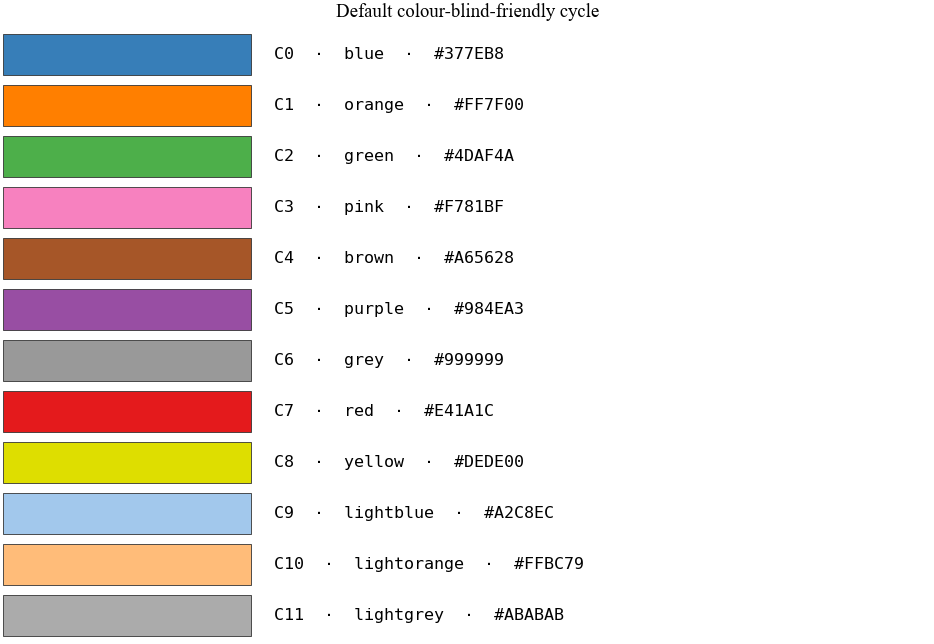

In [6]:
fig = pa.show_colors()
plt.show()

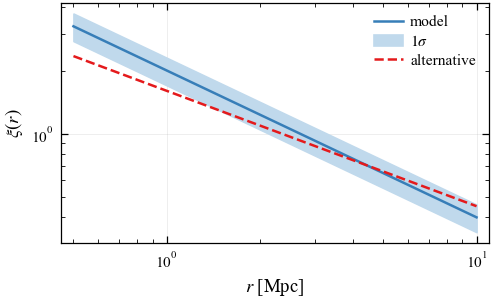

In [7]:
x = np.linspace(0.5, 10, 200)
y = 2 * x ** -0.7

fig, ax = pa.subplots()
ax.plot(x, y, color=pa.COLORS["blue"], label="model")
ax.fill_between(x, 0.85 * y, 1.15 * y,
                color=pa.lighten(pa.COLORS["blue"], 0.7), label=r"$1\sigma$")
ax.plot(x, 1.6 * x ** -0.55, color=pa.COLORS["red"], ls="--", label="alternative")
ax.set_xlabel(r"$r$ [Mpc]")
ax.set_ylabel(r"$\xi(r)$")
ax.loglog()
ax.legend()
plt.show()

`pa.lighten(colour, amount)` and `pa.darken(colour, amount)` create matched
shades — much nicer than `alpha`, because they stay opaque (no colour shifts
where elements overlap, and they print correctly in EPS).

Three more palettes ship with the package:

- `pa.OKABE_ITO` — Okabe & Ito (2008), *the* classic CVD-safe recommendation;
- `pa.PETROFF10` — Petroff (2021), the 10-colour CVD-optimised cycle used
  across particle physics (matplotlib's `petroff10`);
- `pa.PAIRED` — light/dark pairs for data/model or before/after comparisons:
  `pa.PAIRED["blue"]` → `(light, dark)`.

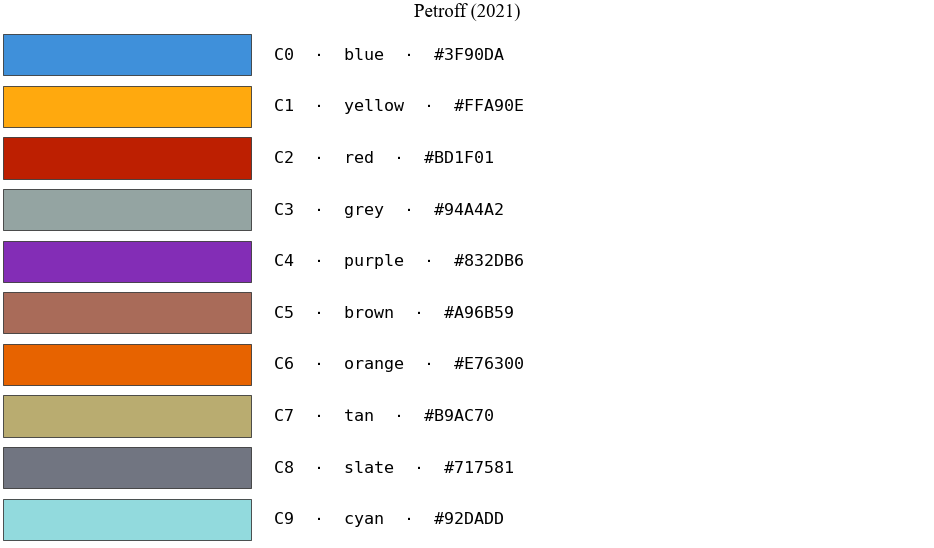

In [8]:
fig = pa.show_colors(pa.PETROFF10, title="Petroff (2021)")
plt.show()

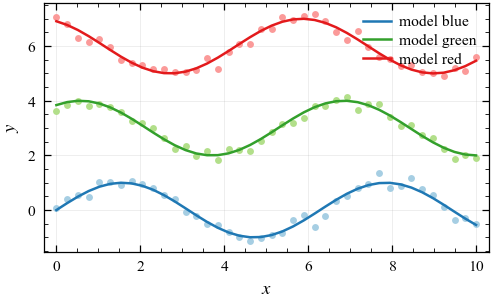

In [9]:
x = np.linspace(0, 10, 40)
fig, ax = pa.subplots()
for i, (name, (light, dark)) in enumerate(list(pa.PAIRED.items())[:3]):
    y = np.sin(x + i) + 3 * i
    ax.plot(x, y + rng.normal(0, 0.18, x.size), "o", ms=2.5, color=light)
    ax.plot(x, y, color=dark, label=f"model {name}")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.legend()
plt.show()

## 4. Checking colour-blind accessibility

Don't take the palette's word for it — check. `pa.check_colors()` shows any
palette under simulated deuteranopia, protanopia and greyscale
(Machado et al. 2009 model, the same one behind most online simulators):

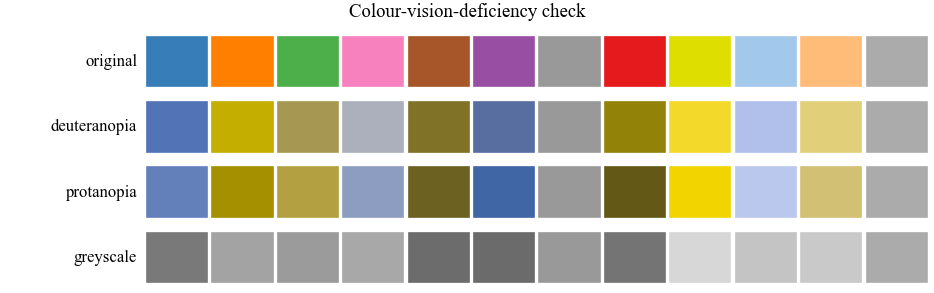

In [10]:
fig = pa.check_colors()          # the default cycle
plt.show()

Even better, `pa.check_figure(fig)` simulates a **whole rendered figure** —
the perfect final check before submitting:

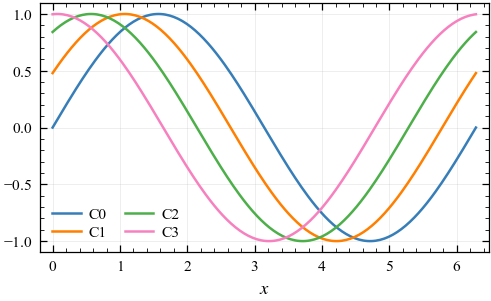

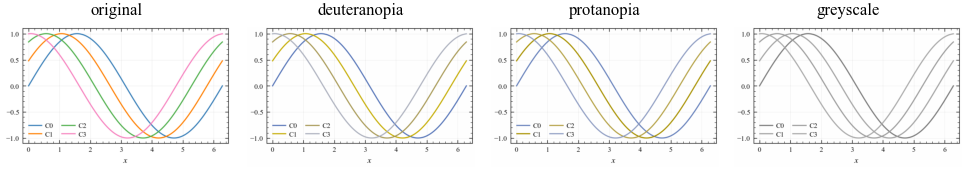

In [11]:
fig, ax = pa.subplots()
x = np.linspace(0, 2 * np.pi, 200)
for i in range(4):
    ax.plot(x, np.sin(x + i / 2), label=f"C{i}")
ax.legend(ncols=2)
ax.set_xlabel("$x$")

check = pa.check_figure(fig)
plt.show()

If two lines merge in any panel, add markers or dash patterns
(next section) or pick colours further apart in the cycle.

## 5. Markers and line styles

`pa.MARKERS` is a sequence chosen to stay distinguishable at small (4 pt)
sizes, and `pa.LINESTYLES` provides named dash patterns beyond matplotlib's
four built-ins:

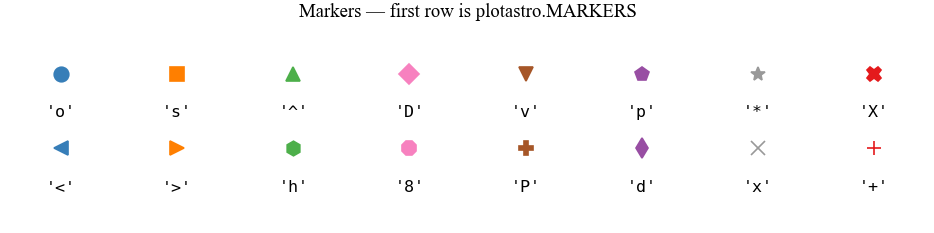

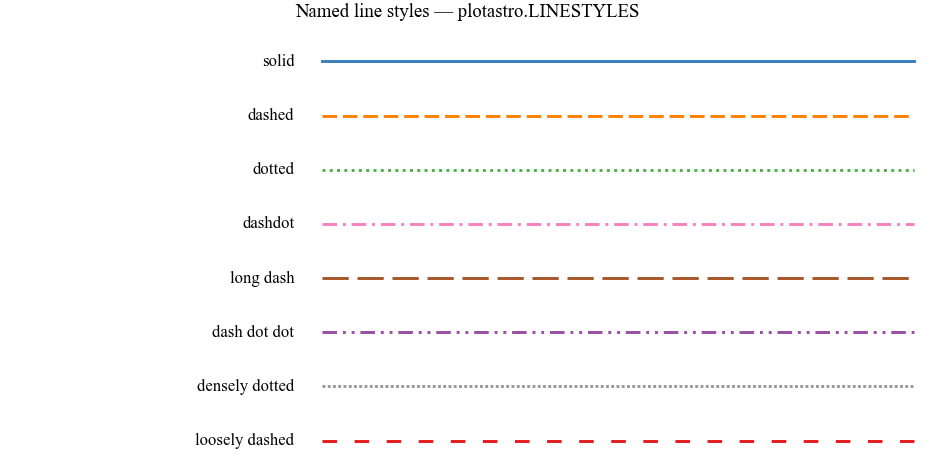

In [12]:
fig = pa.show_markers()
plt.show()
fig = pa.show_linestyles()
plt.show()

### Cycling colours, markers and line styles together

`pa.style_cycler()` builds a property cycle that advances colour, marker
and/or dash pattern *in step* — redundant encoding, so every series is unique
in two or three channels at once and survives greyscale printing.
Use `markevery` to avoid a solid wall of markers on dense data:

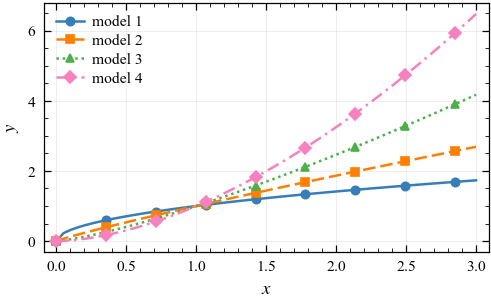

In [13]:
x = np.linspace(0, 3, 60)

fig, ax = pa.subplots()
ax.set_prop_cycle(pa.style_cycler(markers=True, linestyles=True))
for n in range(4):
    ax.plot(x, x ** (0.5 + 0.4 * n), markevery=7, label=f"model {n + 1}")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.legend()
plt.show()

To apply such a cycle to *all* figures instead of a single axes:

```python
plt.rc("axes", prop_cycle=pa.style_cycler(markers=True))
```

## 6. Panel labels

Journals want multi-panel figures labelled (a), (b), (c)... —
`pa.label_panels()` does it in one line, in reading order:

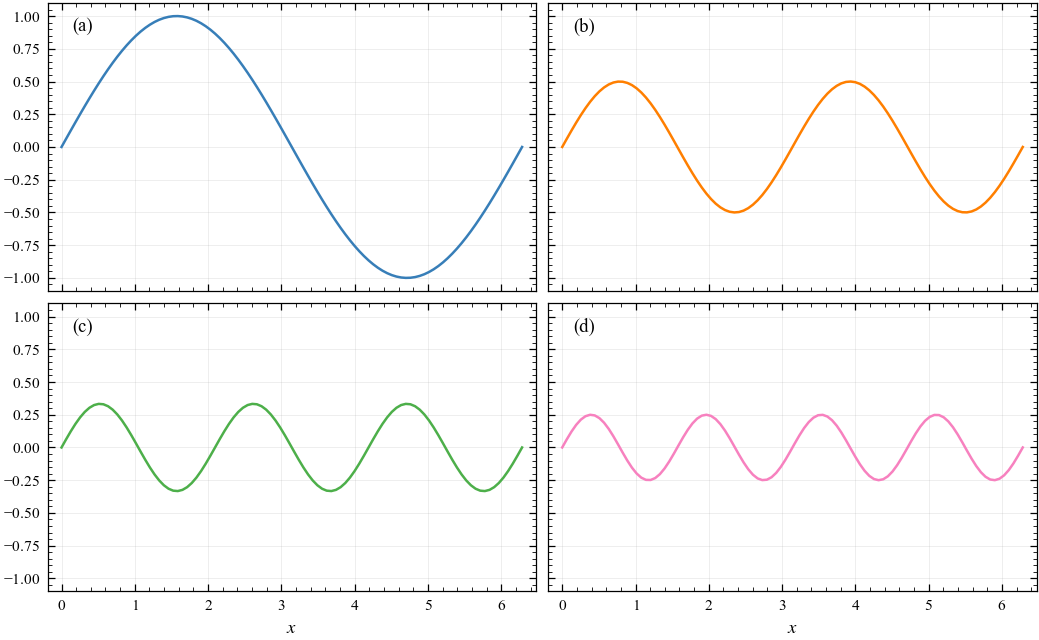

In [14]:
fig, axes = pa.subplots(2, 2, width="full", sharex=True, sharey=True)
x = np.linspace(0, 2 * np.pi, 100)
for i, ax in enumerate(axes.flat):
    ax.plot(x, np.sin((i + 1) * x) / (i + 1), color=f"C{i}")
for ax in axes[1]:
    ax.set_xlabel("$x$")
pa.label_panels(axes)
plt.show()

Options: `loc` ("upper left", "upper right", "lower left", "lower right",
or "outside" for the Nature-style bold letter above the corner), `fmt`
(`"{}."` → "a."), `uppercase=True`, explicit `labels=[...]`, and any `ax.text`
keyword:

```python
pa.label_panels(axes, loc="outside", fmt="{}", fontweight="bold")
```

## 7. Real-world examples

### Data with error bars and a fitted model

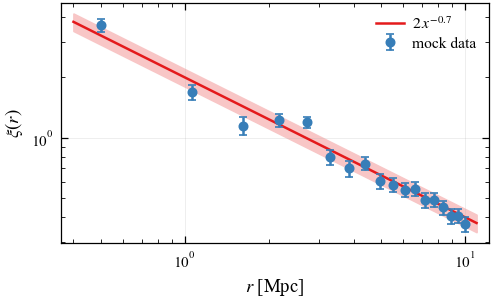

In [15]:
x = np.linspace(0.5, 10, 18)
truth = 2.0 * x ** -0.7
y = truth * rng.normal(1, 0.08, x.size)

fig, ax = pa.subplots()
ax.errorbar(x, y, yerr=0.08 * truth, fmt="o", color=pa.COLORS["blue"],
            label="mock data", zorder=3)
xf = np.linspace(0.4, 11, 200)
ax.plot(xf, 2.0 * xf ** -0.7, color=pa.COLORS["red"], label=r"$2\,x^{-0.7}$")
ax.fill_between(xf, 1.8 * xf ** -0.7, 2.2 * xf ** -0.7,
                color=pa.lighten(pa.COLORS["red"], 0.75), zorder=0)
ax.loglog()
ax.set_xlabel(r"$r$ [Mpc]")
ax.set_ylabel(r"$\xi(r)$")
ax.legend()
plt.show()

### Comparing distributions

Use `histtype="step"` for overlapping histograms — filled histograms hide
each other, stepped ones don't:

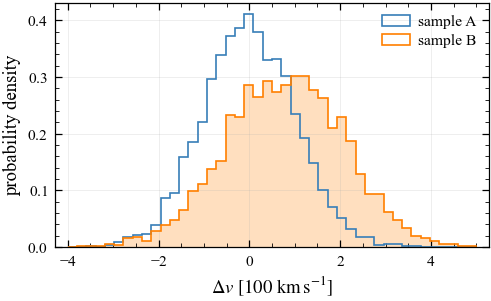

In [16]:
a = rng.normal(0.0, 1.0, 4000)
b = rng.normal(0.8, 1.3, 4000)
bins = np.linspace(-4, 5, 45)

fig, ax = pa.subplots()
ax.hist(a, bins, histtype="step", lw=1.2, label="sample A", density=True)
ax.hist(b, bins, histtype="step", lw=1.2, label="sample B", density=True)
ax.hist(b, bins, color=pa.lighten(pa.COLORS["orange"], 0.75),
        density=True, zorder=0)
ax.set_xlabel(r"$\Delta v\ [100\ \mathrm{km\,s^{-1}}]$")
ax.set_ylabel("probability density")
ax.legend()
plt.show()

### Images with a colour bar

The default colormap is `viridis` (perceptually uniform and colour-blind
safe). For images, a square panel usually looks best — pass `aspect=1`.
For astronomical images you typically also want `origin="lower"`:

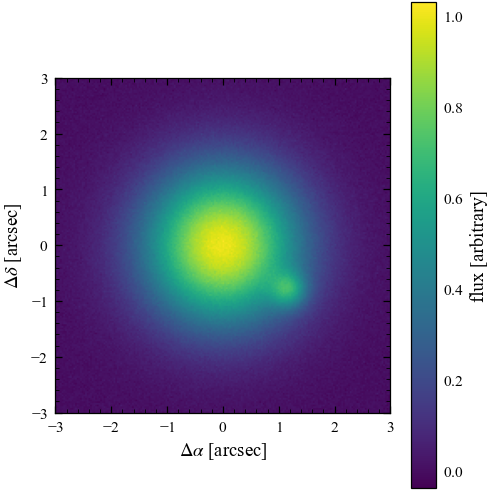

In [17]:
yy, xx = np.mgrid[-3:3:200j, -3:3:200j]
img = np.exp(-(xx**2 + yy**2) / 2) + 0.35 * np.exp(-((xx - 1.2)**2 + (yy + 0.8)**2) / 0.1)
img += rng.normal(0, 0.01, img.shape)

fig, ax = pa.subplots(aspect=1)
im = ax.imshow(img, extent=[-3, 3, -3, 3], origin="lower")
fig.colorbar(im, ax=ax, label="flux [arbitrary]")
ax.set_xlabel(r"$\Delta\alpha$ [arcsec]")
ax.set_ylabel(r"$\Delta\delta$ [arcsec]")
ax.grid(False)
plt.show()

## 8. Switching journals

The styles share one visual language — fonts, colours, tick and legend
settings — and differ only in figure width (and, for Nature Astronomy, the
sans-serif font its guidelines require). Your plots stay consistent across
papers; switching is a single call. Note the sans-serif fonts and single-wide-
column JCAP layout below:

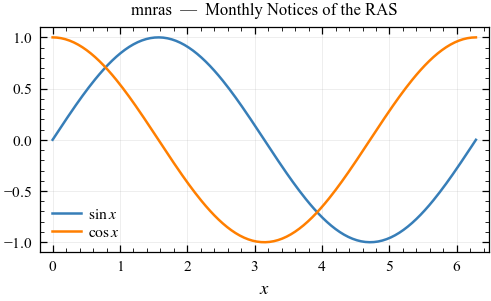

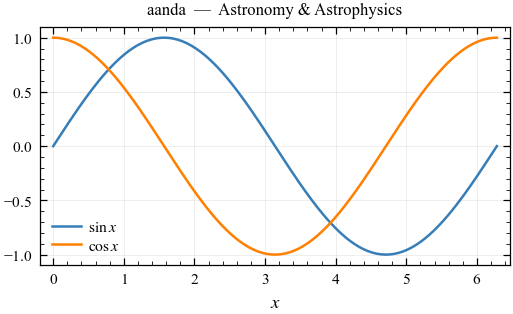

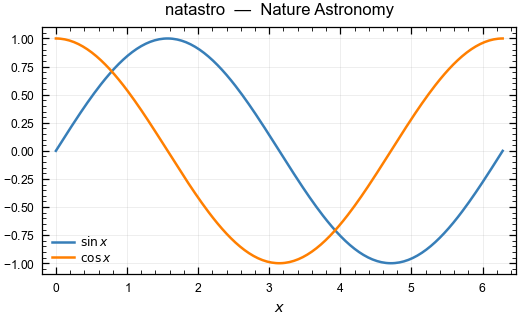

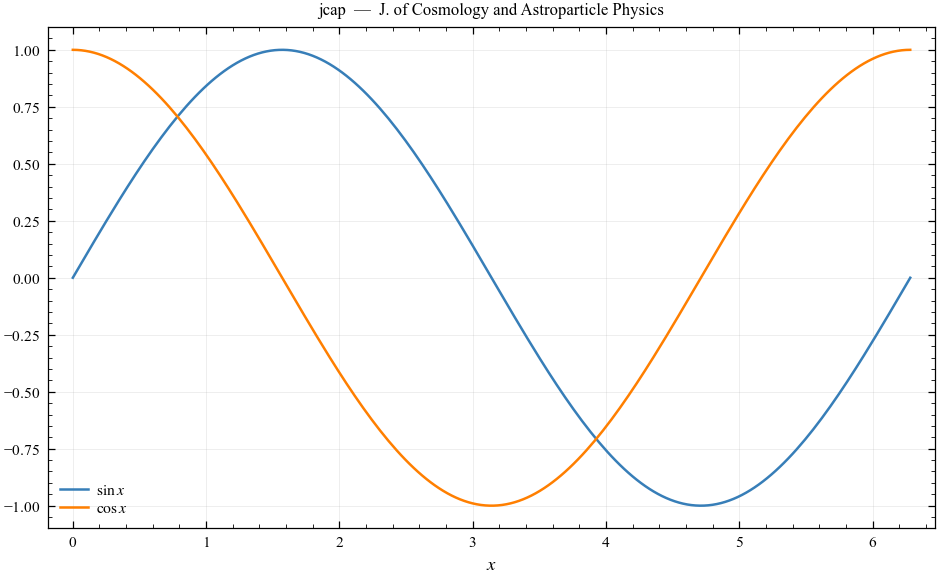

In [18]:
x = np.linspace(0, 2 * np.pi, 200)

for journal in ["mnras", "aanda", "natastro", "jcap"]:
    pa.set_style(journal)
    fig, ax = pa.subplots()
    ax.plot(x, np.sin(x), label=r"$\sin x$")
    ax.plot(x, np.cos(x), label=r"$\cos x$")
    ax.set_title(f"{journal}  —  {pa.JOURNALS[journal]['name']}", fontsize=8)
    ax.set_xlabel("$x$")
    ax.legend()
    plt.show()

pa.set_style("mnras")   # back to default for the rest of the notebook

Also available: `rasti`, `apj`, `oja`, `prd` and the `thesis`/`beamer`
width presets. You can override any rcParam per session:

```python
pa.set_style("mnras", grid=False)                    # no grid
pa.set_style("mnras", **{"font.size": 10})           # bigger fonts
```

## 9. LaTeX text rendering

By default the styles use matplotlib's built-in *mathtext* with STIX fonts —
Times-compatible maths that works everywhere, with no LaTeX installation
required.

If you have LaTeX installed and want pixel-perfect consistency with your
manuscript (custom macros, real kerning), turn on full LaTeX rendering:

```python
pa.set_style("mnras", usetex=True)
```

This uses the `newtx` font packages (the modern Times fonts — MNRAS and A&A
are typeset in Times); for Nature Astronomy it switches to Helvetica instead.
It needs `latex`, `dvipng` and `ghostscript` on your `PATH`, and rendering is
noticeably slower — a good workflow is to develop with `usetex=False` and
flip it on for the final version.

## 10. Saving figures for submission

The styles already save with sensible settings: PDF (vector) by default,
450 dpi for rasterised elements (journals ask for ≥ 300–400 dpi), tight
bounding box, and TrueType fonts embedded (`pdf.fonttype: 42` — avoids the
Type-3 font errors journal submission systems complain about).

`pa.savefig` writes several formats in one call — e.g. a PDF for the
manuscript and a PNG to paste into slides or collaboration chats:

['/var/folders/49/gftfyhj56zs1lz_zs90jcw000000gn/T/tmptg31osma/figure1.pdf',
 '/var/folders/49/gftfyhj56zs1lz_zs90jcw000000gn/T/tmptg31osma/figure1.png']

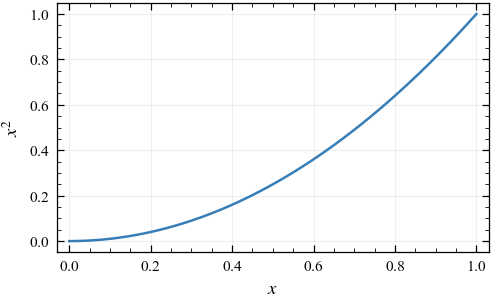

In [19]:
import tempfile, os
outbase = os.path.join(tempfile.mkdtemp(), "figure1")

fig, ax = pa.subplots()
ax.plot(np.linspace(0, 1, 50), np.linspace(0, 1, 50) ** 2)
ax.set_xlabel("$x$")
ax.set_ylabel("$x^2$")

pa.savefig(outbase, fig=fig, formats=("pdf", "png"))

**Per-journal notes**

| journal | accepted figure formats | notes |
|---|---|---|
| MNRAS / RASTI | EPS preferred, PDF/TIFF fine | ≥ 400 dpi raster, ~8 pt lettering, colour-blind friendly required |
| A&A | PDF/EPS | figures 88 mm (column) or 170–180 mm (page) wide |
| ApJ / AAS | PDF/EPS/PNG | vector strongly preferred |
| OJA | PDF (arXiv-ready) | whatever compiles on arXiv works |
| PRD / JCAP | PDF/EPS | vector preferred |
| Nature Astronomy | PDF/EPS/AI | sans-serif fonts, 5–7 pt lettering |

If a journal insists on EPS, note EPS has **no transparency** — replace
`alpha=` with `pa.lighten()` shades (another reason they are the better
habit).

## 11. Author lists from a CSV

Assembling the author/affiliation block by hand is error-prone on long
collaborations. Feed plotastro the author CSV your collaboration already
maintains — it recognises `Authorname` (or `name`, or `Firstname` +
`Lastname`), `Affiliation` (several separated by `;`, or one row per
affiliation — repeated author rows are merged) and optional `ORCID`/`Email`
columns, ignores everything else (`JoinedAsBuilder`, ...), strips stray
spaces, and passes through LaTeX accents like `\'{e}` untouched.
Affiliations are numbered in order of first appearance and shared between
authors automatically; the first author with an email becomes the
corresponding author. Here's a realistic list:

In [20]:
print(open("authors_example.csv").read())

Lastname,Firstname,Authorname,Email,JoinedAsBuilder,Affiliation,ORCID,
Bandi,Behnood,Behnood Bandi, b.bandi@sussex.ac.uk, False,"Astronomy Centre, University of Sussex, Falmer, Brighton BN1 9QH, UK",0000-0001-5838-3903,
Rocher,Antoine,Antoine Rocher,antoine.rocher@epfl.ch,False,"EPFL, \'{E}cole polytechnique f\'{e}d\'{e}rale de Lausanne, Chemin des Maillettes, 51, 1290 Versoix, Switzerland",0000-0003-4349-6424,
Verdier,Aur\'{e}lien,Aur\'{e}lien Verdier,aurelien.verdier@epfl.ch,False,"EPFL, \'{E}cole polytechnique f\'{e}d\'{e}rale de Lausanne, Chemin des Maillettes, 51, 1290 Versoix, Switzerland",,
Richard,Johan,Johan Richard,johan.richard@univ-lyon1.fr,False,"CRAL, Centre de Recherche Astrophysique de Lyon, Universit\'{e} de Lyon, 9 avenue Charles Andr\'{e}, 69230 Saint-Genis-Laval, France",0000-0001-5492-1049,
Loveday,Jon ,Jon Loveday, j.loveday@sussex.ac.uk, False,"Astronomy Centre, University of Sussex, Falmer, Brighton BN1 9QH, UK",0000-0001-5290-8940,
Brown,Michael,Michael Brown,m

In [21]:
print(pa.authorlist("authors_example.csv", journal="mnras"))

% Author list generated by plotastro (mnras format)
% Check addresses/footnotes against the journal template.
\author[B. Bandi et al.]{
Behnood Bandi,$^{1}$\thanks{E-mail: b.bandi@sussex.ac.uk}
Antoine Rocher,$^{2}$
Aur\'{e}lien Verdier,$^{2}$
Johan Richard,$^{3}$
Jon Loveday$^{1}$
and Michael Brown$^{4}$
\\
% List of institutions
$^{1}$Astronomy Centre, University of Sussex, Falmer, Brighton BN1 9QH, UK\\
$^{2}$EPFL, \'{E}cole polytechnique f\'{e}d\'{e}rale de Lausanne, Chemin des Maillettes, 51, 1290 Versoix, Switzerland\\
$^{3}$CRAL, Centre de Recherche Astrophysique de Lyon, Universit\'{e} de Lyon, 9 avenue Charles Andr\'{e}, 69230 Saint-Genis-Laval, France\\
$^{4}$Monash, School of Physics and Astronomy, Monash University, Wellington Road, Clayton, VIC 3800, Australia
}


In [22]:
print(pa.authorlist("authors_example.csv", journal="apj"))

% Author list generated by plotastro (apj format)
% Check addresses/footnotes against the journal template.
\correspondingauthor{Behnood Bandi}
\email{b.bandi@sussex.ac.uk}

\author[0000-0001-5838-3903]{Behnood Bandi}
\affiliation{Astronomy Centre, University of Sussex, Falmer, Brighton BN1 9QH, UK}

\author[0000-0003-4349-6424]{Antoine Rocher}
\affiliation{EPFL, \'{E}cole polytechnique f\'{e}d\'{e}rale de Lausanne, Chemin des Maillettes, 51, 1290 Versoix, Switzerland}

\author{Aur\'{e}lien Verdier}
\affiliation{EPFL, \'{E}cole polytechnique f\'{e}d\'{e}rale de Lausanne, Chemin des Maillettes, 51, 1290 Versoix, Switzerland}

\author[0000-0001-5492-1049]{Johan Richard}
\affiliation{CRAL, Centre de Recherche Astrophysique de Lyon, Universit\'{e} de Lyon, 9 avenue Charles Andr\'{e}, 69230 Saint-Genis-Laval, France}

\author[0000-0001-5290-8940]{Jon Loveday}
\affiliation{Astronomy Centre, University of Sussex, Falmer, Brighton BN1 9QH, UK}

\author[0000-0002-1207-9137]{Michael Brown}
\affi

The same CSV works for every journal the package knows — `mnras`/`rasti`,
`aanda`, `apj`/`oja` (AASTeX), `prd` (REVTeX), `jcap`, or `generic` for a
plain numbered block. There is also a command-line tool, so co-authors who
don't use Python can run it too:

```bash
plotastro-authors authors.csv --journal aanda
plotastro-authors authors.csv -j apj -o authors.tex
```

That's it — happy plotting! See `README.md` for the full reference.